In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt


        



In [ ]:
class MLP(nn.Module):
    def __init__(self, seq_length, input_size=1, hidden_dims=(64, 32), dropout=0.1):
        super().__init__()
        in_dim = seq_length * input_size
        layers = []
        prev = in_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers += [nn.Linear(prev, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        # accepts (B, T) or (B, T, F)
        if x.dim() == 2:
            x = x.reshape(x.size(0), -1)
        elif x.dim() == 3:
            x = x.reshape(x.size(0), -1)
        else:
            raise ValueError(f"Expected 2D or 3D input, got shape {tuple(x.shape)}")
        return self.net(x)


In [3]:
class TimeSeriesDataset(Dataset):
    def __init__(self, target_data, exog_data, seq_length):
        """
        Dataset for time series with optional exogenous variables.
        
        Args:
            target_data: Scaled target variable data
            exog_data: Scaled exogenous variables data (can be None)
            seq_length: Length of input sequences
        """
        self.target_data = target_data
        self.exog_data = exog_data
        self.seq_length = seq_length
        self.has_exog = exog_data is not None
    
    def __len__(self):
        return len(self.target_data) - self.seq_length
    
    def __getitem__(self, idx):
        # Target sequence and label
        target_seq = self.target_data[idx:idx+self.seq_length]
        y = self.target_data[idx+self.seq_length]
        
        if self.has_exog:
            # Combine target with exogenous variables
            exog_seq = self.exog_data[idx:idx+self.seq_length]
            # Stack target and exog features: shape (seq_length, 1 + n_exog)
            x = np.column_stack([target_seq.reshape(-1, 1), exog_seq])
        else:
            x = target_seq.reshape(-1, 1)
        
        return torch.FloatTensor(x), torch.FloatTensor([y])



In [ ]:
def mlp_experiment(df, target, train_size=500, val_size=100, forecast_window=161, 
                   seq_length=30, epochs=100, batch_size=32, lr=0.001, dropout=0.2, hidden_size=64, num_layers=2, exog=None, plot=False):
    """
    MLP time series forecasting experiment
    """
    # Split data
    total_train_val = train_size + val_size
    train = df[target][-(total_train_val+forecast_window):-(val_size+forecast_window)].values
    val = df[target][-(val_size+forecast_window):-forecast_window].values
    test = df[target][-forecast_window:].values
    
    # Normalize data
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train.reshape(-1, 1)).flatten()
    val_scaled = scaler.transform(val.reshape(-1, 1)).flatten()
    # Note: Test data is not scaled here as we use it for evaluation in original scale

    exog_scaler = None
    exog_train_scaled = None
    exog_val_scaled = None
    exog_test_scaled = None
    
    if exog is not None:
        exog_train = df[exog][-(total_train_val+forecast_window):-(val_size+forecast_window)].values
        exog_val = df[exog][-(val_size+forecast_window):-forecast_window].values
        # The test set exogenous variables (known future)
        exog_test = df[exog][-forecast_window:].values
        
        exog_scaler = MinMaxScaler()
        exog_train_scaled = exog_scaler.fit_transform(exog_train)
        exog_val_scaled = exog_scaler.transform(exog_val)
        exog_test_scaled = exog_scaler.transform(exog_test)

    input_size = 1 + (len(exog) if exog else 0)
    
    # Create datasets
    train_dataset = TimeSeriesDataset(train_scaled, exog_train_scaled, seq_length)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    val_dataset = TimeSeriesDataset(val_scaled, exog_val_scaled, seq_length)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # Initialize model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    model = MLP(seq_length=seq_length, input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, dropout=dropout).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # Training loop
    train_losses = []
    val_losses = []
    
    best_val_loss = float('inf')
    best_model_path = 'best_mlp_model.pth'
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_train_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # Validation phase
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item()
                
        avg_val_loss = val_loss / len(val_loader) if len(val_loader) > 0 else 0
        val_losses.append(avg_val_loss)
        
        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), best_model_path)
        
        if plot and (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}')
    
    # Load best model for forecasting
    #model.load_state_dict(torch.load(best_model_path))
    
    # Forecasting
    model.eval()
    
    # Initial sequence from validation data
    current_seq = val_scaled[-seq_length:].tolist()
    if exog is not None:
         exog_history = exog_val_scaled[-seq_length:].tolist()

    forecast = []
    with torch.no_grad():
        for step in range(forecast_window):
             # 1. Prepare input x
             if exog is not None:
                  input_arr = np.column_stack([np.array(current_seq).reshape(-1, 1), np.array(exog_history)])
                  x_tensor = torch.FloatTensor(input_arr).unsqueeze(0).to(device)
             else:
                  x_tensor = torch.FloatTensor(np.array(current_seq).reshape(-1, 1)).unsqueeze(0).to(device)
             
             # 2. Predict y_hat (for step 'step')
             pred = model(x_tensor).cpu().numpy()[0, 0]
             forecast.append(pred)
             
             # 3. Update history for next step prediction
             current_seq = current_seq[1:] + [pred]
             
             if exog is not None:
                  current_exog = exog_test_scaled[step]
                  exog_history = exog_history[1:] + [current_exog.tolist()]

    
    # Inverse transform predictions
    forecast = scaler.inverse_transform(np.array(forecast).reshape(-1, 1)).flatten()
    
    # Evaluate
    rmse = np.sqrt(mean_squared_error(test, forecast))
    mae = mean_absolute_error(test, forecast)
    
    if plot:
        # Visualize results
        _, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
        
        # Plot forecast vs actual
        train_index = df[target][-(total_train_val+forecast_window):-(val_size+forecast_window)].index
        val_index = df[target][-(val_size+forecast_window):-forecast_window].index
        test_index = df[target][-forecast_window:].index
        
        ax1.plot(train_index, train, label='Train', alpha=0.7)
        ax1.plot(val_index, val, label='Validation', alpha=0.7, color='orange')
        ax1.plot(test_index, test, label='Actual Test', linewidth=2)
        ax1.plot(test_index, forecast, label='Forecast', linestyle='--', linewidth=2)
        ax1.legend()
        ax1.set_title('MLP Forecast vs Actual')
        ax1.set_xlabel('Time')
        ax1.set_ylabel(target)
        ax1.grid(True, alpha=0.3)
        
        # Plot training loss
        ax2.plot(train_losses, label='Train Loss')
        ax2.plot(val_losses, label='Validation Loss')
        ax2.legend()
        ax2.set_title('Training and Validation Loss')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('MSE Loss')
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    return model, scaler, exog_scaler, forecast, rmse, mae, test


In [5]:
ITEM_ID = 26008           # Example item_id from sample_head.csv
STORE_ID = 6269        # Example store_id from sample_head.csv
DATA_PATH = '../dataset/data_andre.feather' # Adjust path if needed
TARGET_COL = 'value'
DATE_COL = 'date'

EPOCHS = 1000            # Set a bit higher to ensure convergence, though fewer should be needed
BATCH_SIZE = 32         # Smaller batch size for more frequent updates
LEARNING_RATE = 0.001  # Standard LR
HIDDEN_SIZE = 64      # Increased capacity
DROPOUT = 0.2       # Regularization to prevent overfitting

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cpu


In [ ]:
# -----------------------------------------------------------------------------
# DATA LOADING & PREPROCESSING
# -----------------------------------------------------------------------------
DATA_PATH = '../dataset/subset_set.feather'  # Adjust path if needed
print(f"Loading data from {DATA_PATH}...")
# Use pd.read_feather instead of feather.read_table to get a DataFrame directly
df_full = pd.read_feather(DATA_PATH)

print(f"Filtering for Item: {ITEM_ID}, Store: {STORE_ID}...")
# Filter for specific item and store
df = df_full[(df_full['item_id'] == ITEM_ID) & (df_full['store_id'] == STORE_ID)].copy()

# Reset index to avoid ambiguity if 'date' is also in the index
df = df.reset_index(drop=True)

# Ensure date is datetime and sort
df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.sort_values(DATE_COL)

# -----------------------------------------------------------------------------
# FEATURE ENGINEERING (EXOGENOUS VARIABLES)
# -----------------------------------------------------------------------------
# 1. Day of week (0=Monday, 6=Sunday)
df['day_of_week'] = df[DATE_COL].dt.dayofweek

# 2. Month (1=January, 12=December)
df['month'] = df[DATE_COL].dt.month

# 3. Day of month (1-31) - captures paydays
df['day_of_month'] = df[DATE_COL].dt.day

# 4. Is Weekend (Binary)
df['is_weekend'] = (df['day_of_week'] >= 5).astype(float)

# 5. Promotions
# Identify all columns that start with 'promo_'
promo_cols = [col for col in df.columns if col.startswith('promo_')]
print(f"Found {len(promo_cols)} promotion columns: {promo_cols}")

# Ensure promo columns are numeric (float)
for col in promo_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(float)

# Define the list of exogenous features to use
EXOG_COLS = None
#EXOG_COLS = ['day_of_week', 'month', 'day_of_month', 'is_weekend'] + promo_cols
print(f"Created exogenous features: {EXOG_COLS}")

# Prepare target variable
# Using 'value' as the target (sales/demand)
y = df[TARGET_COL]

print(len(y))


# -----------------------------------------------------------------------------
# DATA SPLITTING
# -----------------------------------------------------------------------------
# Define split sizes
train_size = 450
val_size = 150
forecast_horizon = 161

lookback_window = 30


Loading data from ../dataset/subset_set.feather...
Filtering for Item: 26008, Store: 6269...
Found 16 promotion columns: ['promo_type_FRPG', 'promo_value_FRPG', 'promo_type_GAS', 'promo_value_GAS', 'promo_type_BOGO', 'promo_value_BOGO', 'promo_type_DISC', 'promo_value_DISC', 'promo_type_CIRC', 'promo_value_CIRC', 'promo_type_CIRE', 'promo_value_CIRE', 'promo_type_CLCP', 'promo_value_CLCP', 'promo_type_LFPE', 'promo_value_LFPE']
Created exogenous features: None
761


Training MLP with train_size=450, val_size=160, forecast_horizon=161, lookback_window=30...
Epoch [10/1000], Train Loss: 0.011399, Val Loss: 0.002418
Epoch [20/1000], Train Loss: 0.009702, Val Loss: 0.001797
Epoch [30/1000], Train Loss: 0.008101, Val Loss: 0.001897
Epoch [40/1000], Train Loss: 0.007205, Val Loss: 0.001841
Epoch [50/1000], Train Loss: 0.006651, Val Loss: 0.001926
Epoch [60/1000], Train Loss: 0.005268, Val Loss: 0.001828
Epoch [70/1000], Train Loss: 0.005044, Val Loss: 0.001875
Epoch [80/1000], Train Loss: 0.004589, Val Loss: 0.001776
Epoch [90/1000], Train Loss: 0.004454, Val Loss: 0.001982
Epoch [100/1000], Train Loss: 0.004070, Val Loss: 0.001836
Epoch [110/1000], Train Loss: 0.004518, Val Loss: 0.001853
Epoch [120/1000], Train Loss: 0.004386, Val Loss: 0.001843
Epoch [130/1000], Train Loss: 0.003453, Val Loss: 0.001887
Epoch [140/1000], Train Loss: 0.003101, Val Loss: 0.001838
Epoch [150/1000], Train Loss: 0.002859, Val Loss: 0.001852
Epoch [160/1000], Train Loss: 0.

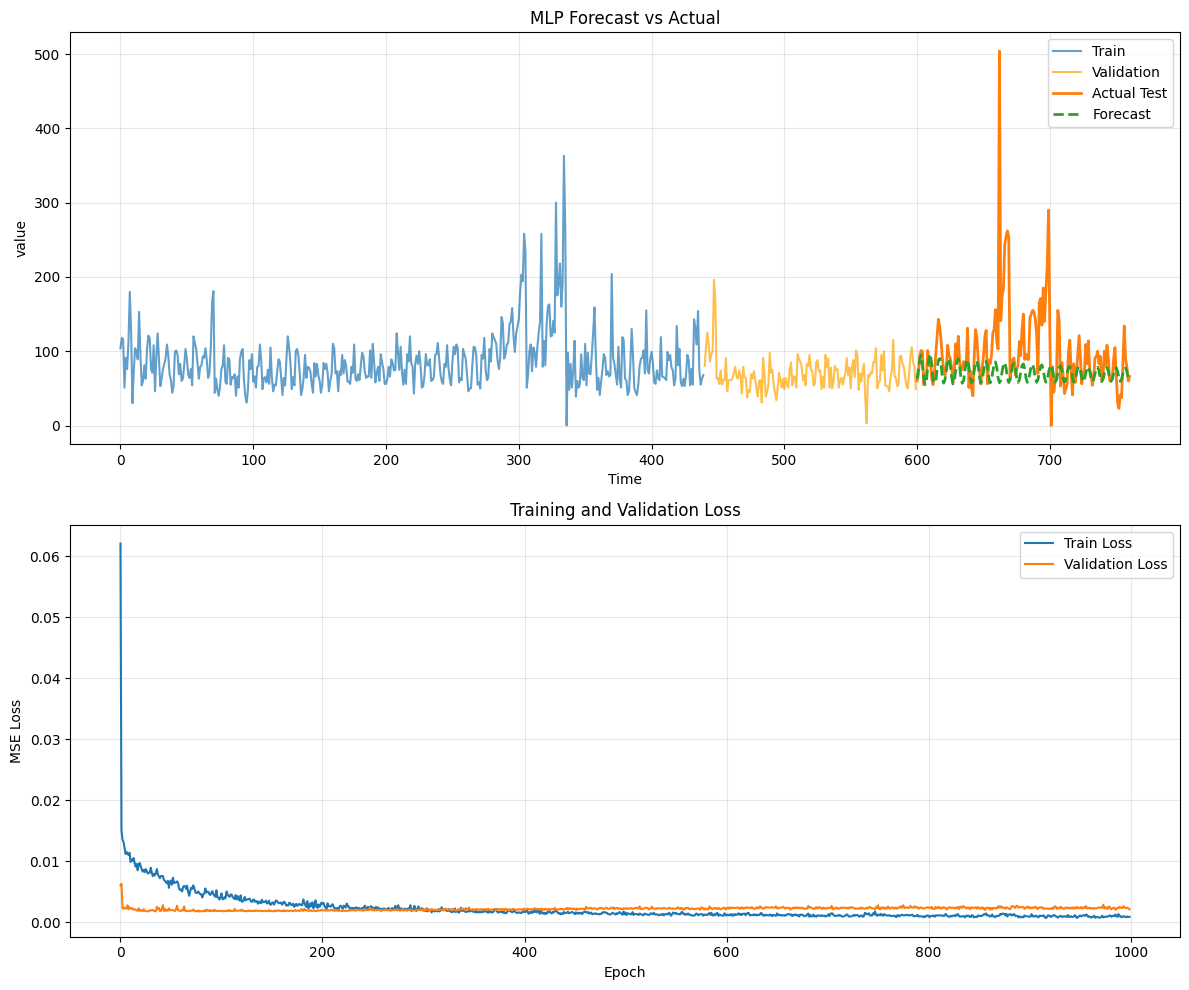

RMSE: 61.8867
MAE: 35.1144


In [7]:
print(f"Training MLP with train_size={train_size}, val_size={val_size}, forecast_horizon={forecast_horizon}, lookback_window={lookback_window}...")

model, scaler, exog_scaler, forecast, rmse, mae, test = mlp_experiment(
    df=df, 
    target=TARGET_COL, 
    train_size=train_size, 
    val_size=val_size,
    forecast_window=forecast_horizon, 
    seq_length=lookback_window, 
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE, 
    lr=LEARNING_RATE, 
    dropout=DROPOUT,
    hidden_size=HIDDEN_SIZE, # You can try different sizes
    num_layers=2,   # You can try different number of layers
    exog=EXOG_COLS, # Pass the exogenous variable list
    plot=True
)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
